# Final Project for Computational Electromagnetics

## Olivares Nunez, Itzel

# Assignment 5


## A.5.1. Problem description

We seek the capacitance per unit length of  a circular conducting wire placed over the middle of a conducting strip. The wire radius is $a$ , and the center of the wire is located at a height $h$ over the strip. The strip has width $w$ and thickness $b$. The geometry is assumed to be two-dimensional and the structure is located in free space. For the computation of the capacitance per unit, it is therefore appropiate to use the method of moments.


For a capacitor where two plates have different shape, the two plates must have opposite total charges. However, they will not in general have opposite potentials. Since Poisson’s equation is linear, the charges and potentials must satisfy the linear relation

$$
q_1 = C_{11}V_1 + C_{12}V_2
$$

$$
q_2 = C_{21}V_1 + C_{22}V_2
$$

where $q_i$ are the charges on the plates and $V_i$ their potentials. The matrix elements $C_{ij}$ are referred to as capacitance coefficients. Note that the capacitance coefficients in themselves are not physically very relevant and they depend on how the normalizing distance is chosen in the expression for the potential from a line charge. The coefficients can be computed by considering two cases where $V_1$ and $V_2$ take linearly independent values, e.g.,

1. $V_1 = 1$ and $V_2 = 0$ yield the values for $C_{11}$ and $C_{21}$.
2. $V_1 = 0$ and $V_2 = 1$ yield the values for $C_{11}$ and $C_{22}$.

To define the capacitance in cylindrical geometry, we consider cases where the net charge is zero. This implies that $q_1 = -q_2 = q$. Then the capacitance is defined as

$$
C = \frac{q}{V_1-V_2}
$$

# Assignments

First express the net capacitance $C$ **analytically** in terms of the capacitance coefficients $C_{11}$, $C_{12}$, $C_{21}$ and $C_{22}$. 



## Implementation

The following program evaluates the capacitance of a general 2D, two-conductor capacitor and geometry part to generate the geometry described previously. The function MOM2D was provided in the class in reference to the MATLAB function 2DMOM.m described in Sect. 7.2.2 of the book.


In [1]:
function MoM2D(xs, ys, xe, ye, ϕ)
       
    xobs = 0.5.*(xs + xe)    # Observation points
    yobs = 0.5.*(ys + ye)
    h = sqrt.((xe-xs).^2  + (ye - ys).^2)  # Length of elements
    A = zeros(Float64, length(xs),length(xs))#Matriz para integral
    
    #Loop over elements
    for k in eachindex(xs)
        s = ( (xobs .- xs[k])*(xe[k] .- xs[k])
            + (yobs .- ys[k])*(ye[k] .- ys[k]))./h[k]^2;
        
        d = real(sqrt.(convert.(Complex{Float64}, (xobs .- xs[k]).^2 + (yobs .- ys[k]).^2 - s.^2 .* h[k]^2 .+ 1e-24)))
        # 1e-24 is a simple hack to avoid dealing with ξe/d blowing up to infinity for d=0
        # note that d.*atan.(ξe./d) = 0 for d = 0 (analytically)
        # same is true for x*ln (x^2 + d^2)

        ξs = -s.*h[k]
        ξe = (1 .- s).*h[k]
        
        temp = 0.5*ξe.*log.(ξe.^2 + d.^2) - ξe + d.*atan.(ξe./d) - 
            (0.5*ξs.*log.(ξs.^2 + d.^2) - ξs + d.*atan.(ξs./d))
        A[:, k] = -temp[:]/(2*π*8.854187)  
    end
    σ = (A\ϕ)      # Charge density
    q = h.*σ       # Charge per element
    return q, σ
end



MoM2D (generic function with 1 method)

The following fuction **get_capacitance** discretizes the geometry described in the problem description. 

For that, the center of the wire was place at the origin of the cartesian grid. 

The geometry of the wire was considered into two parts: (i) the top circunference with positive y values, and the (ii) bottom circunference with negative y values.

The geometry of the conducting strip was considered into four parts. The (iii) top and (iv) bottom lines parallel to the x-axis, and the (v)left and (vi)right lines parallel to the y-axis.

The elements length, $h$, was also different for each of the geometry elements. A specific $h$ was calculated for the whole wire, for the top and bottom lines of the strip, and for the left and right lines of the strip. 

In [2]:
"""
    get_capacitance(a, w, b, d, n)
    
    Returns the capacitance of a circular conducting wire placed over the middle of a conducting strip.
    The discretization is made based on the value of the given argument n.
    
    Arguments:
        a = wire radius
        w = width of the strip
        b = thickness of the strip
        d = height of center of the wire over the strip
        n = number of segments

    Returns:
        C = capacitance

"""


function get_capacitance(a, w, b, d, n)

    nh              = round(Int64,n/2)  # Number of elements for wire/strip
    
    nh_half_wire    = round(Int64,nh/2) # Number of elements for each top & bottom circunference halves of wire
    h_wire          = 2*a/nh            # Length of the elements in the wire
    
    nh_strip        = round(Int64,nh/4) # Number of elements for each side of the strip
    h_strip         = w/nh_strip        # Length of the elements for the strip width
    h_strip_b       = b/nh_strip        # Length of the elements for the strip thickness

# X-coordinates for starting and ending points
    xs              = zeros(n) 
    xe              = zeros(n)
    
    # Wire's upper half:
    xs[1:nh_half_wire] = collect(range(-a, stop=a-h_wire, length=nh_half_wire)) 
    # Wire's bottom half:
    xs[nh_half_wire+1:2*nh_half_wire] = collect(range(-a, stop=a-h_wire, length=nh_half_wire))
    # Strip's top part:
    xs[2*nh_half_wire+1:2*nh_half_wire+nh_strip] = collect(range(-0.5*w, stop=0.5*w-h_strip, length=nh_strip))
    # Strip's right part: 
    xs[2*nh_half_wire+nh_strip+1: 2*nh_half_wire+2*nh_strip]= ones(nh_strip).*(0.5*w) 
    # Strip's bottom part
    xs[2*nh_half_wire+2*nh_strip+1:2*nh_half_wire+3*nh_strip]= collect(range(-0.5*w, stop=0.5*w-h_strip, length=nh_strip))
    # Strip's left part
    xs[2*nh_half_wire+3*nh_strip+1:2*nh_half_wire+4*nh_strip]= ones(nh_strip).*(-0.5*w) 

    # Whole wire:
    xe[1:2*nh_half_wire] = xs[1:2*nh_half_wire] .+ h_wire
    # Strip's top part:
    xe[2*nh_half_wire+1:2*nh_half_wire+nh_strip] = xs[2*nh_half_wire+1:2*nh_half_wire+nh_strip] .+ h_strip 
    # Strip's right part: 
    xe[2*nh_half_wire+nh_strip+1: 2*nh_half_wire+2*nh_strip] = xs[2*nh_half_wire+nh_strip+1: 2*nh_half_wire+2*nh_strip] 
    # Strip's bottom part:
    xe[2*nh_half_wire+2*nh_strip+1:2*nh_half_wire+3*nh_strip] = xs[2*nh_half_wire+2*nh_strip+1:2*nh_half_wire+3*nh_strip] .+ h_strip 
    # Strip's left part:
    xe[2*nh_half_wire+3*nh_strip+1:2*nh_half_wire+4*nh_strip]= ones(nh_strip).*(-0.5*w)
    
# Y-coordinates for starting and ending points
    ys              = zeros(n)   
    ye              = zeros(n)
    
    
    #For calculating the y-coordinates for the wire, I considered the circle's formula x^2+y^2=r^2
    # Wire's upper half:
    for (index,value) in enumerate(xs[1:nh_half_wire])
        ys[index] = sqrt(a^2 - value^2)
    end

    for (index,value) in enumerate(xe[1:nh_half_wire])
        ye[index] = sqrt(a^2 - value^2)
    end
    
    # Wire's bottom half:

    for (index,value) in enumerate(xs[nh_half_wire+1:2*nh_half_wire])
        ys[index+nh_half_wire] = -sqrt(a^2 - value^2)
    end

    for (index,value) in enumerate(xe[nh_half_wire+1:2*nh_half_wire])
        ye[index+nh_half_wire] = -sqrt(a^2 - value^2)
    end
    
    
    # Strip's top part:
    ys[2*nh_half_wire+1:2*nh_half_wire+nh_strip] = ones(nh_strip).*(-d) 
    ye[2*nh_half_wire+1:2*nh_half_wire+nh_strip] = ys[2*nh_half_wire+1:2*nh_half_wire+nh_strip] 

    # Strip's right part:
    ys[2*nh_half_wire+nh_strip+1: 2*nh_half_wire+2*nh_strip]= collect(range(-d-b, stop=-d-h_strip_b, length=nh_strip)) 
    ye[2*nh_half_wire+nh_strip+1: 2*nh_half_wire+2*nh_strip]= ys[2*nh_half_wire+nh_strip+1: 2*nh_half_wire+2*nh_strip] .+ h_strip_b

    # Strip's bottom part:
    ys[2*nh_half_wire+2*nh_strip+1:2*nh_half_wire+3*nh_strip]= ones(nh_strip).*(-d-b) 
    ye[2*nh_half_wire+2*nh_strip+1:2*nh_half_wire+3*nh_strip]= ones(nh_strip).*(-d-b)

    # Strip's left part:
    ys[2*nh_half_wire+3*nh_strip+1:2*nh_half_wire+4*nh_strip]= collect(range(-d-b, stop=-d-h_strip_b, length=nh_strip))
    ye[2*nh_half_wire+3*nh_strip+1:2*nh_half_wire+4*nh_strip]= ys[2*nh_half_wire+3*nh_strip+1:2*nh_half_wire+4*nh_strip] .+ h_strip_b

# Potential for the elements
    V                                               = zeros(n)    
    V[1:2*nh_half_wire]                             = ones(2*nh_half_wire).*(1)
    V[2*nh_half_wire+1:2*nh_half_wire+4*nh_strip]   = ones(4*nh_strip).*(0)

# Solve the electrostatic problem
    q, σ = MoM2D(xs, ys, xe, ye, V)
    C = sum(q[1:nh])
    return C
    
end



get_capacitance (generic function with 1 method)

# Numerical Test #1

Test the program by running the case $a =$  1 mm, $b=$ 0.5 mm, $d =$  2 mm, and $w =$ 20 mm. Determine the order of convergence and make an extrapolation to zero grid size within 1% accuracy. 

In [3]:
using Printf
a = 1 
b = 0.5 
d = 2 
w = 20

# n  MUST BE A MULTIPLE OF 8
for n in [80 160 200 280 400]
    @printf("%6d %14.10f \n", 
                n, 
                get_capacitance(a, w, b, d, n))
end

    80  40.4738929952 
   160  41.0035735550 
   200  41.0671650297 
   280  41.1344579128 
   400  41.1829683473 


Estimated order of convergence: 0.9726673707206521
41.4051 - 7253.91*x


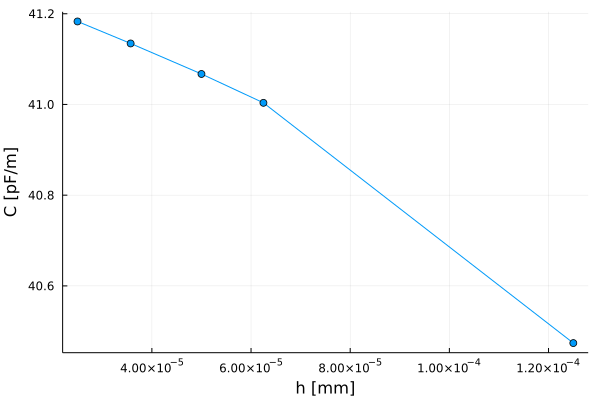

In [4]:
using Polynomials
using Plots

function estimate_p(h, I)
    return log((I[end-2] - I[end-1])/(I[end-1] - I[end]))/log(h[end-2]/h[end-1])
end

# n_vals MUST BE MULTIPLES OF 8

n_vals = [80; 160; 200; 280; 400]
h      = 0.01./n_vals
C      = [get_capacitance(a, w, b, d, n) for n in n_vals]

p = estimate_p(h, C)
println("Estimated order of convergence: ", p)
pfit = fit(h.^1, C, 1)
println(pfit)

gr()
plot(h.^1, C, marker=:circle, 
                    xlabel="h [mm]", 
                    ylabel="C [pF/m]", 
                    legend=false)


## Numerical Test #2

Verify that your result for $C$ is reasonably close to the analytical result for an infinite plate, i.e., $w = \infty$. (The analytical result can be derived by means of image theory for a circular cylinder next to an infinitely large ground plate, where details can be found in [19].) For this part, give the extrapolated coefficient $C_{ij}$ as intermediate results. 

We know that
$$
q_1 = C_{11}V_1 + C_{12}V_2
$$

$$
q_2 = C_{21}V_1 + C_{22}V_2
$$

can be represented in matrix form as:
$$ 
\begin{pmatrix}
    q_1 \\
    q_2
\end{pmatrix}
=
\begin{pmatrix}
    C_{11} & C_{12} \\
    C_{21} & C_{22} 
\end{pmatrix}
\begin{pmatrix}
    V_1 \\
    V_2
\end{pmatrix}
$$

For the case when $V_1 = 1$ and $V_2 = 0$, we get:

$$ 
\begin{pmatrix}
    q_1 \\
    q_2
\end{pmatrix}
=
\begin{pmatrix}
    C_{11}  \\
    C_{21}  
\end{pmatrix}
$$

thus
$$
C_{11} =  -C_{21}
$$

and for the case when when $V_1 = 0$ and $V_2 = 1$, we get:
$$
C_{12} =  -C_{22}
$$


The equation 3-158 calculated in [19] for the Method of Images states that:
$$ 
\begin{pmatrix}
    V_1 \\
    V_2
\end{pmatrix}
=
\begin{pmatrix}
    \frac{-\rho_{l}}{2\pi \varepsilon_{0}} \ln{(\frac{a}{d})}  \\
    \frac{\rho_{l}}{2\pi \varepsilon_{0}} \ln{(\frac{a}{d})}  
\end{pmatrix}
$$

Considering $V_1 = 1$ and $V_2 = 0$, $a = 1$, $b = -D$ we get:

\begin{aligned}
    \rho_{l} &= 42.22645
\end{aligned} 

When filling our capacitance coefficient matrix, by means of C=Q/v we get:
$$
\begin{bmatrix}
   42.22645 & -42.22645 \\
   -42.22645 & 42.22645
\end{bmatrix}
$$

To find the net capacitance, we sum the diagonal elements $$ C_{11} + C_{22} = 84.4529 \space pF/mm $$
which correspond to the therms $C_{ii}, C_{ij}$

## Numerical Test #3

Keeping all the other parameters the same, set $w =$  0.5 mm. Check the order of convergence and extrapolate to zero grid size, with at most 1% error. 

In [5]:
using Printf
a = 1 
b = 0.5 
d = 2 
w = 0.5

# n  MUST BE A MULTIPLE OF 8
for n in [80 160 200 280 400]
    @printf("%6d %14.10f \n", 
                n, 
                get_capacitance(a, w, b, d, n))
end

    80 -86.3329455874 
   160 -84.8300588876 
   200 -84.5314711705 
   280 -84.1871799693 
   400 -83.9239244229 


For this project I collaborated with Xue, Yuchen and Ramireddy, Saicharan Reddy.